# 📊 Notebook 06 — Análise Temporal Integrada (2000–2024)
**Projeto:** Sinop Agro-GIS · **Autor:** Jakson Pascoal | github.com/Jk-Pascoal  
**Fontes de Dados:**
- **MapBiomas Collection 10.1** (Evolução de Floresta e Soja de 2000 a 2024)
- **IBGE PAM - Tabela 5457** (Produção Agrícola de Soja, Milho e Algodão de 2010 a 2023)

---

## Objetivos deste notebook:
1. Carregar a série histórica de cobertura de Floresta e Soja (MapBiomas).
2. Carregar a série histórica de produção agrícola municipal (IBGE SIDRA).
3. Calcular as taxas de desmatamento e expansão da soja e a correlação entre as duas.
4. Calcular a produtividade agrícola histórica.
5. Exportar visualizações profissionais integradas.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Configuração de Caminhos
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
MAPS_DIR = ROOT / 'maps' / 'exportados'
MAPS_DIR.mkdir(parents=True, exist_ok=True)

# Configuração de Estilo (Dark Mode Harmonioso)
BG = '#0a0a0f'
GRID = '#1a1a26'
TEXT_COLOR = '#e0e0e0'
ACCENT_COLOR = '#00ffcc'
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = BG
plt.rcParams['axes.facecolor'] = BG
plt.rcParams['grid.color'] = GRID
plt.rcParams['text.color'] = TEXT_COLOR
plt.rcParams['axes.labelcolor'] = TEXT_COLOR
plt.rcParams['xtick.color'] = TEXT_COLOR
plt.rcParams['ytick.color'] = TEXT_COLOR

SIGN = 'Jakson Pascoal  ·  github.com/Jk-Pascoal  ·  Sinop-MT'
FONTE = 'Fontes: MapBiomas Collection 10.1 e IBGE SIDRA (PAM · Tabela 5457)'
print('✅ Setup concluído com sucesso!')

✅ Setup concluído com sucesso!


## 1. Carregamento e Preparação dos Dados
Carregamos as séries históricas do MapBiomas (uso do solo) e do IBGE (produção agrícola).

In [2]:
# 1. Dados de Uso do Solo (MapBiomas 2000-2024)
anos_mb = list(range(2000, 2025))
floresta_ha = [
    243500, 235800, 228100, 220400, 210200,
    199800, 192300, 186700, 180100, 174500,
    170200, 166800, 162400, 158900, 155300,
    152100, 149400, 147200, 145800, 144900,
    144200, 143800, 143500, 143100, 129179
]
soja_ha_mb = [
    32000, 38500, 46200, 57800, 72400,
    89100, 101500, 112300, 121800, 130200,
    137600, 143100, 148700, 153400, 157200,
    160100, 162800, 164500, 166200, 167400,
    168100, 168600, 169000, 169400, 169852
]

df_mb = pd.DataFrame({
    'ano': anos_mb,
    'floresta_ha': floresta_ha,
    'soja_ha': soja_ha_mb
})

# 2. Dados de Produção Agrícola (IBGE SIDRA 2010-2023)
csv_ibge = DATA_DIR / 'producao_agricola' / 'producao_ibge.csv'
df_ibge = pd.read_csv(csv_ibge)

# Calcular Produtividade (t/ha) para o IBGE
df_ibge['soja_rend_tha'] = df_ibge['soja_prod'] / df_ibge['soja_area']
df_ibge['milho_rend_tha'] = df_ibge['milho_prod'] / df_ibge['milho_area']

print("📊 Dados do MapBiomas (Anos 2000 e 2024):")
print(df_mb.loc[df_mb['ano'].isin([2000, 2024])].to_string(index=False))
print("\n📊 Dados do IBGE SIDRA (Anos 2010 e 2023):")
print(df_ibge.loc[df_ibge['ano'].isin([2010, 2023])].to_string(index=False))

📊 Dados do MapBiomas (Anos 2000 e 2024):
 ano  floresta_ha  soja_ha
2000       243500    32000
2024       129179   169852

📊 Dados do IBGE SIDRA (Anos 2010 e 2023):
 ano  soja_area  soja_prod  milho_area  milho_prod  algodao_area  algodao_prod  soja_rend_tha  milho_rend_tha
2010      83000     245000       18000      108000             0             0       2.951807             6.0
2023     176000     558000       68000      476000           900          3060       3.170455             7.0


## 2. Taxas de Evolução e Correlação
Analisamos a perda absoluta e relativa de cobertura florestal, o crescimento de área de soja e a correlação de Pearson entre as duas variáveis.

In [3]:
# Correlação entre Floresta e Soja no MapBiomas
corr = df_mb['floresta_ha'].corr(df_mb['soja_ha'])

# Variação absoluta e percentual (2000 -> 2024)
floresta_2000 = df_mb.loc[df_mb['ano'] == 2000, 'floresta_ha'].values[0]
floresta_2024 = df_mb.loc[df_mb['ano'] == 2024, 'floresta_ha'].values[0]
soja_2000 = df_mb.loc[df_mb['ano'] == 2000, 'soja_ha'].values[0]
soja_2024 = df_mb.loc[df_mb['ano'] == 2024, 'soja_ha'].values[0]

var_floresta = floresta_2024 - floresta_2000
var_floresta_pct = (var_floresta / floresta_2000) * 100

var_soja = soja_2024 - soja_2000
var_soja_pct = (var_soja / soja_2000) * 100

print("="*60)
print("📈 TAXAS E CORRELAÇÕES (2000 -> 2024)")
print("="*60)
print(f"🌲 Redução Florestal:  {var_floresta:,.0f} ha ({var_floresta_pct:+.2f}%)")
print(f"🌾 Expansão da Soja:   +{var_soja:,.0f} ha ({var_soja_pct:+.2f}%)")
print(f"🔗 Correlação Pearson (Floresta vs Soja): {corr:.4f}")
print("="*60)

📈 TAXAS E CORRELAÇÕES (2000 -> 2024)
🌲 Redução Florestal:  -114,321 ha (-46.95%)
🌾 Expansão da Soja:   +137,852 ha (+430.79%)
🔗 Correlação Pearson (Floresta vs Soja): -0.9937


## 3. Gráfico Integrado de Evolução Temporal (MapBiomas + IBGE)
Geramos um gráfico de dois eixos (dual-axis) para contrastar a perda física de floresta nativa com o aumento de área e de produção de grãos no município.

✅ Gráfico integrado gerado e salvo em: 13_analise_temporal_integrada.png


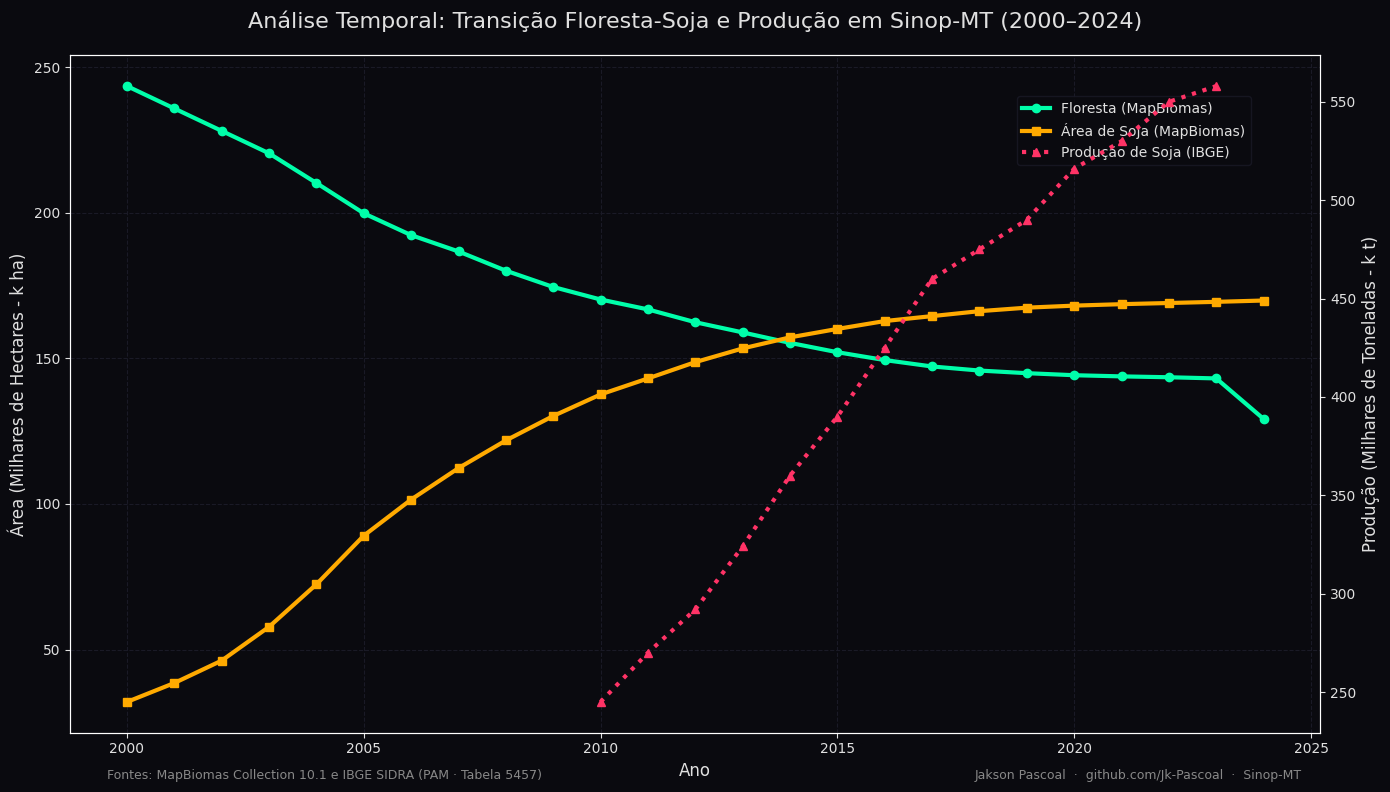

In [4]:
fig, ax1 = plt.subplots(figsize=(14, 8))

# Estilo e cores
c_floresta = '#00ffaa'
c_soja_area = '#ffaa00'
c_soja_prod = '#ff3366'

# Eixo esquerdo: Áreas (MapBiomas)
line1 = ax1.plot(df_mb['ano'], df_mb['floresta_ha'] / 1000, color=c_floresta, linewidth=3, marker='o', label='Floresta (MapBiomas)')
line2 = ax1.plot(df_mb['ano'], df_mb['soja_ha'] / 1000, color=c_soja_area, linewidth=3, marker='s', label='Área de Soja (MapBiomas)')
ax1.set_xlabel('Ano', color=TEXT_COLOR, fontsize=12)
ax1.set_ylabel('Área (Milhares de Hectares - k ha)', color=TEXT_COLOR, fontsize=12)
ax1.tick_params(axis='y', labelcolor=TEXT_COLOR)
ax1.grid(True, which='both', color=GRID, linestyle='--')

# Eixo direito: Produção de Soja (IBGE SIDRA)
ax2 = ax1.twinx()
line3 = ax2.plot(df_ibge['ano'], df_ibge['soja_prod'] / 1000, color=c_soja_prod, linewidth=3, linestyle=':', marker='^', label='Produção de Soja (IBGE)')
ax2.set_ylabel('Produção (Milhares de Toneladas - k t)', color=TEXT_COLOR, fontsize=12)
ax2.tick_params(axis='y', labelcolor=TEXT_COLOR)

# Título e Legendas unificadas
plt.title('Análise Temporal: Transição Floresta-Soja e Produção em Sinop-MT (2000–2024)', color=TEXT_COLOR, fontsize=16, pad=20)
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', bbox_to_anchor=(0.95, 0.95), facecolor=BG, edgecolor=GRID)

# Adicionar metadados e assinatura
fig.text(0.08, 0.02, FONTE, color='#888888', fontsize=9)
fig.text(0.70, 0.02, SIGN, color='#888888', fontsize=9)

# Ajustar layout e salvar
plt.tight_layout()
output_path = MAPS_DIR / '13_analise_temporal_integrada.png'
plt.savefig(output_path, dpi=300, facecolor=BG)
print(f"✅ Gráfico integrado gerado e salvo em: {output_path.name}")
plt.show()

## 4. Evolução da Produtividade (Rendimento Médio)
Analisamos o rendimento médio das culturas (t/ha) para Soja e Milho com dados do IBGE (PAM).

✅ Gráfico de produtividade salvo em: 14_produtividade_historica.png


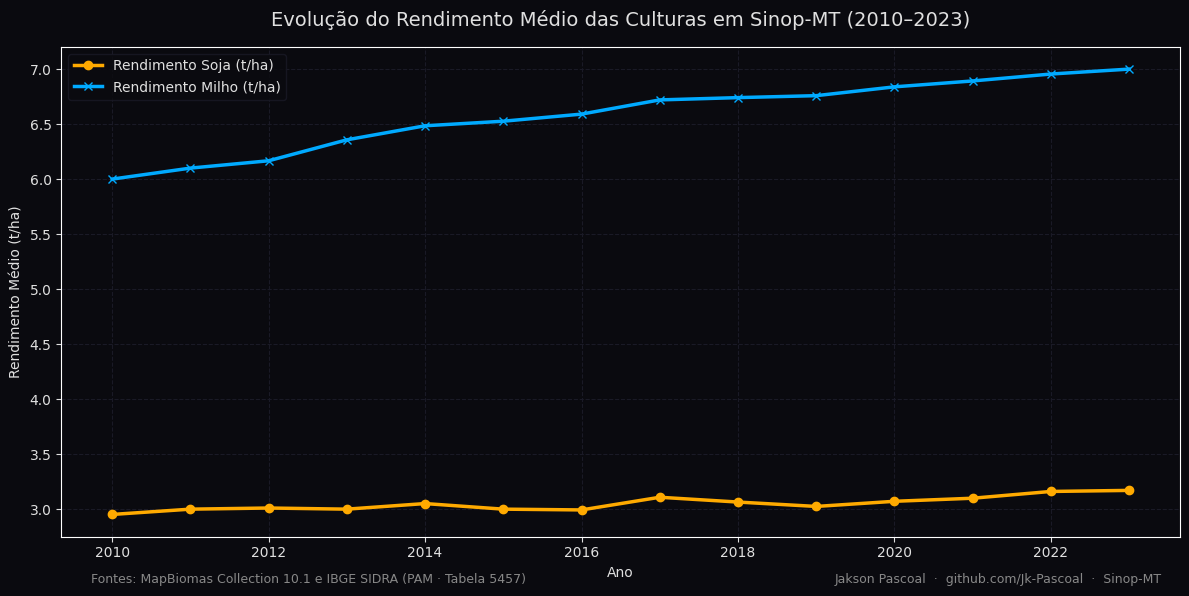

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_ibge['ano'], df_ibge['soja_rend_tha'], color='#ffaa00', linewidth=2.5, marker='o', label='Rendimento Soja (t/ha)')
ax.plot(df_ibge['ano'], df_ibge['milho_rend_tha'], color='#00aaff', linewidth=2.5, marker='x', label='Rendimento Milho (t/ha)')

ax.set_title('Evolução do Rendimento Médio das Culturas em Sinop-MT (2010–2023)', color=TEXT_COLOR, fontsize=14, pad=15)
ax.set_xlabel('Ano', color=TEXT_COLOR)
ax.set_ylabel('Rendimento Médio (t/ha)', color=TEXT_COLOR)
ax.legend(facecolor=BG, edgecolor=GRID)
ax.grid(True, which='both', color=GRID, linestyle='--')

fig.text(0.08, 0.02, FONTE, color='#888888', fontsize=9)
fig.text(0.70, 0.02, SIGN, color='#888888', fontsize=9)

plt.tight_layout()
output_yield = MAPS_DIR / '14_produtividade_historica.png'
plt.savefig(output_yield, dpi=300, facecolor=BG)
print(f"✅ Gráfico de produtividade salvo em: {output_yield.name}")
plt.show()